In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from scipy.optimize import curve_fit


import random
import string
import utilities.plotting_style as pstyle

pstyle.apply_style()  # uses your module defaults (fonts, palette, cmap, etc.)

/Users/yannisvassiliadis/code/playground/utilities/src/utilities/plotting_style.py:210: UserWarning: Overwriting the cmap 'Coconut' that was already in the registry.
  mpl.colormaps.register(cmap, force=True)  # mpl>=3.5-ish


PlotFonts(base=<matplotlib.font_manager.FontProperties object at 0x13ff1c990>, bold=<matplotlib.font_manager.FontProperties object at 0x108994110>)

In [90]:
letter_count = 3
number_count = 4
n_simulations = 10_000_000

seed = 23#random.randrange(1_000_000_000)
print(f"seed = {seed}")

seed = 23


In [30]:
def get_plate_letters(n = letter_count, max_letter = None):

    if max_letter is None:
        plate_letters = ''.join(random.choices(string.ascii_uppercase, k = letter_count))
    else:
        plate_letters = ''.join(random.choices(string.ascii_uppercase[:(string.ascii_uppercase.find(max_letter)+1)], k = letter_count))
    return plate_letters

In [31]:
def get_plate_numbers(n = number_count, leading_zero = False):
    
    if not leading_zero:
        plate_numbers = random.choice(string.digits[1:]) + ''.join(random.choices(string.digits, k = number_count - 1)) # no leading 0
    else:
        plate_numbers = ''.join(random.choices(string.digits, k = number_count))
    return plate_numbers


In [32]:
def get_license_plate(letter_count=letter_count, 
                      number_count=number_count,
                      max_letter=None, 
                      leading_zero=False):

    plate_letters = get_plate_letters(letter_count, max_letter)
    plate_numbers = get_plate_numbers(number_count, leading_zero)

    license_plate = plate_letters + plate_numbers

    return license_plate, plate_letters, plate_numbers

In [33]:
def is_sorted(s):

    return ''.join(sorted(s)) == s

def is_palindrome(s):
    
    return s == s[::-1]

In [34]:
def plate_is_sorted(plate):

    _, letters, numbers = plate   # ignore the full plate string

    letters_sorted = letters == ''.join(sorted(letters))
    numbers_sorted = numbers == ''.join(sorted(numbers))
    plate_sorted = letters_sorted and numbers_sorted

    return (
        plate_sorted,
        letters_sorted,
        numbers_sorted,
    )

In [35]:
def plate_is_palindrome(plate):

    _, letters, numbers = plate

    letters_palindrome = letters == letters[::-1]
    numbers_palindrome = numbers == numbers[::-1]
    plate_palindrome = letters_palindrome and numbers_palindrome

    return (
        plate_palindrome,
        letters_palindrome,
        numbers_palindrome,
    )

In [36]:
VERTICAL_SYMMETRIC_LETTERS = set("AHIMOTUVWXY")
VERTICAL_SYMMETRIC_DIGITS = set("018")

In [37]:
def plate_is_symmetric_palindrome(plate):

    _, letters, numbers = plate

    return (
        letters[0] in VERTICAL_SYMMETRIC_LETTERS and
        letters[1] in VERTICAL_SYMMETRIC_LETTERS and
        numbers[0] in VERTICAL_SYMMETRIC_DIGITS and
        numbers[1] in VERTICAL_SYMMETRIC_DIGITS
    )

In [38]:
def simulate_plates(n_simulations, **kwargs):
    results = []

    for _ in range(n_simulations):
        plate = get_license_plate(**kwargs)
        license_plate, letters, numbers = plate

        plate_sorted, letters_sorted, numbers_sorted = plate_is_sorted(plate)
        plate_palindrome, letters_palindrome, numbers_palindrome = plate_is_palindrome(plate)

        symmetric_palindrome = False
        if plate_palindrome:
            symmetric_palindrome = plate_is_symmetric_palindrome(plate)

        results.append({
            'license_plate': license_plate,
            'letters': letters,
            'numbers': numbers,
            'plate_sorted': plate_sorted,
            'letters_sorted': letters_sorted,
            'numbers_sorted': numbers_sorted,
            'plate_palindrome': plate_palindrome,
            'letters_palindrome': letters_palindrome,
            'numbers_palindrome': numbers_palindrome,
            'symmetric_palindrome': symmetric_palindrome,
        })

    return pd.DataFrame(results)

In [63]:
plate_results = simulate_plates(n_simulations)

plate_results.head()

,license_plate,letters,numbers,plate_sorted,letters_sorted,numbers_sorted,plate_palindrome,letters_palindrome,numbers_palindrome,symmetric_palindrome
0,SQY8785,SQY,8785,False,False,False,False,False,False,False
1,XKY7434,XKY,7434,False,False,False,False,False,False,False
2,DDA2715,DDA,2715,False,False,False,False,False,False,False
3,PJJ5988,PJJ,5988,False,False,False,False,False,False,False
4,HGV1910,HGV,1910,False,False,False,False,False,False,False


In [64]:
plate_results['starting_letter'] = plate_results['license_plate'].apply(lambda x: x[0])

In [65]:
plate_results.groupby('starting_letter').plate_sorted.agg(['mean', 'sum', 'count'])

,mean,sum,count
starting_letter,,,
A,0.028685,11028,384449
B,0.026446,10164,384333
C,0.024720,9523,385241
D,0.022247,8563,384909
E,0.020704,7952,384079
F,0.018860,7260,384945
G,0.017286,6643,384292
H,0.015713,6054,385285
I,0.014106,5422,384362


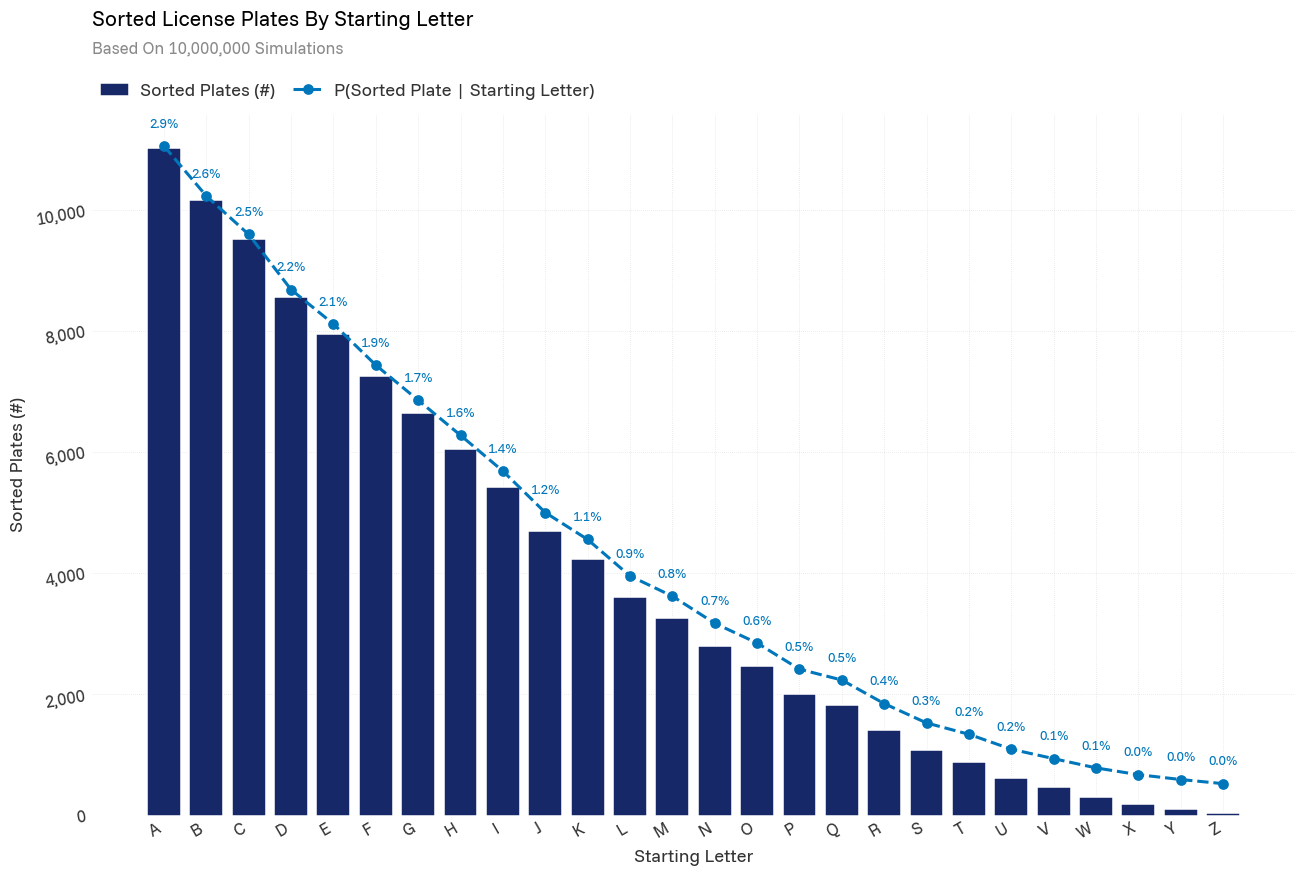

In [66]:
agg = (
    plate_results
    .groupby("starting_letter")["plate_sorted"]
    .agg(sum="sum", mean="mean")
    .sort_index()
)

x_labels = agg.index.astype(str).tolist()
x = np.arange(len(x_labels))

sum_vals = agg["sum"].to_numpy(dtype=float)
mean_vals = agg["mean"].to_numpy(dtype=float)

fig, ax1 = plt.subplots()

# Bars: sum (primary axis)
ax1.bar(x, sum_vals, label="Sorted Plates (#)")
ax1.set_ylabel("Sorted Plates (#)")
ax1.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Line: mean (secondary axis, hidden)
ax2 = ax1.twinx()

# ensure no gridlines from the secondary axis
ax2.grid(False)
ax1.grid(True)              # optional: keep primary grid
ax1.set_axisbelow(True)

ax2.plot(
    x,
    mean_vals,
    linestyle="--",
    linewidth=2,
    color="C1",
    marker="o",
    label="P(Sorted Plate | Starting Letter)",
)

# Hide secondary axis visuals (keep the line)
ax2.set_ylabel("")
ax2.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
ax2.spines["right"].set_visible(False)

# Annotate mean values with extra padding
for xi, m in zip(x, mean_vals):
    ax2.annotate(
        f"{m:.1%}",
        (xi, m),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        va="bottom",
        fontsize=9,
        color="C1",
    )

# X formatting
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45, ha="right")
ax1.set_xlabel("Starting Letter")

pstyle.set_title(
    ax1,
    "Sorted License Plates by Starting Letter",
    f"Based on {n_simulations:,} simulations",
)

pstyle.style_plot(
    ax1,
    format_thousands_axis="y",
    legend_axes=[ax2],
)


plt.tight_layout()
plt.show()


In [74]:
transition = agg.diff()

transition["sum_decrease"] = -transition["sum"]
transition["mean_decrease"] = -transition["mean"]

transition = transition.iloc[1:]
transition.head()

,sum,mean,sum_decrease,mean_decrease
starting_letter,,,,
B,-864.0,-0.002239,864.0,0.002239
C,-641.0,-0.001726,641.0,0.001726
D,-960.0,-0.002473,960.0,0.002473
E,-611.0,-0.001543,611.0,0.001543
F,-692.0,-0.001844,692.0,0.001844


In [75]:
letters = agg.index.astype(str).tolist()

transition_labels = [
    f"{letters[i]}-->{letters[i+1]}"
    for i in range(len(letters) - 1)
]

transition_labels[:3]

['A-->B', 'B-->C', 'C-->D']

In [80]:
x = np.arange(len(transition_labels))

sum_vals = transition["sum"].to_numpy()
mean_vals = transition["mean"].to_numpy()

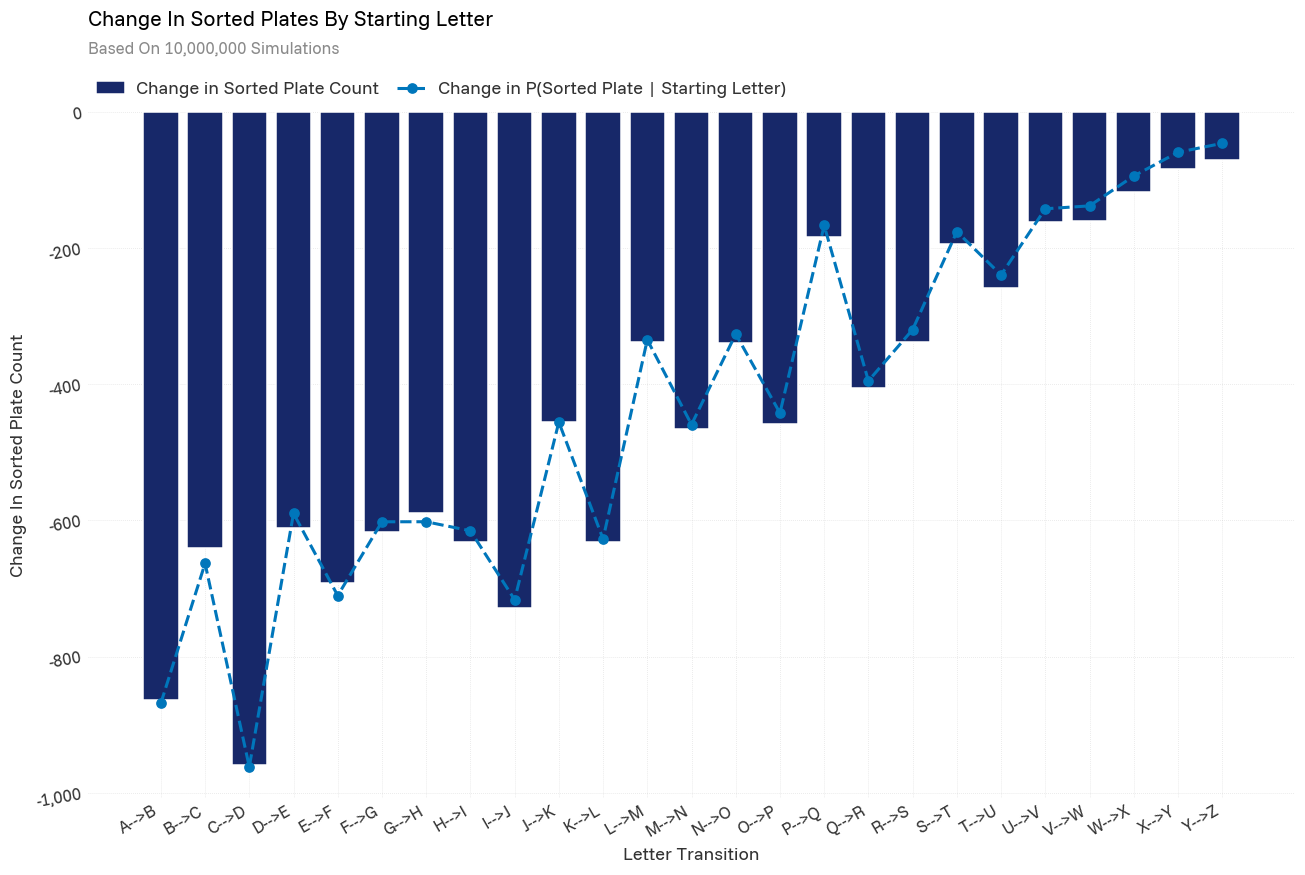

In [82]:
fig, ax1 = plt.subplots()

# Bars: decrease in count
ax1.bar(x, sum_vals, label="Change in Sorted Plate Count")
ax1.set_ylabel("Change in Sorted Plate Count")

# Line: decrease in mean
ax2 = ax1.twinx()
ax2.grid(False)

ax2.plot(
    x,
    mean_vals,
    linestyle="--",
    linewidth=2,
    marker="o",
    color="C1",
    label="Change in P(Sorted Plate | Starting Letter)",
)

# Hide secondary axis visuals
ax2.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
ax2.spines["right"].set_visible(False)

# X axis
ax1.set_xticks(x)
ax1.set_xticklabels(transition_labels, rotation=45, ha="right")
ax1.set_xlabel("Letter Transition")

# Title
pstyle.set_title(
    ax1,
    "Change in Sorted Plates by Starting Letter",
    f"Based on {n_simulations:,} simulations",
)

pstyle.style_plot(
    ax1,
    format_thousands_axis="y",
    legend_axes=[ax2],
)

plt.tight_layout()
plt.show()


In [91]:
x = np.arange(len(agg))
y = agg["mean"].to_numpy()

def exp_model(x, a, b):
    return a * np.exp(b * x)

def quad_model(x, a, b, c):
    return a + b*x + c*x**2

def cubic_model(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

def power_model(x, a, b):
    return a * (x + 1) ** b


In [98]:
models = {
    "quadratic": (quad_model, 3),
    "power": (power_model, 2),
}

fits = {}

# --- exponential (log-linear fit) ---
log_y = np.log(y)
b, log_a = np.polyfit(x, log_y, 1)
a = np.exp(log_a)

y_pred = a * np.exp(b * x)

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot

fits["exponential"] = ((a, b), y_pred, r2)

print("exponential")
print(f"model: y = {a:.6e} * exp({b:.6f} x)")
print(f"R²: {r2:.6f}\n")

# --- other models ---
for name, (func, k) in models.items():
    params, _ = curve_fit(func, x, y, maxfev=10000)
    y_pred = func(x, *params)

    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot

    fits[name] = (params, y_pred, r2)

    print(name)

    if name == "quadratic":
        a, b, c = params
        print(f"model: y = {a:.6e} + {b:.6e}x + {c:.6e}x²")

    elif name == "power":
        a, b = params
        print(f"model: y = {a:.6e} * (x+1)^{b:.6f}")

    print(f"R²: {r2:.6f}\n")


exponential
model: y = 5.399580e-02 * exp(-0.187782 x)
R²: 0.364541

quadratic
model: y = 2.869795e-02 + -2.177891e-03x + 4.136475e-05x²
R²: 0.999727

power
model: y = 3.649944e-02 * (x+1)^-0.571257
R²: 0.755991



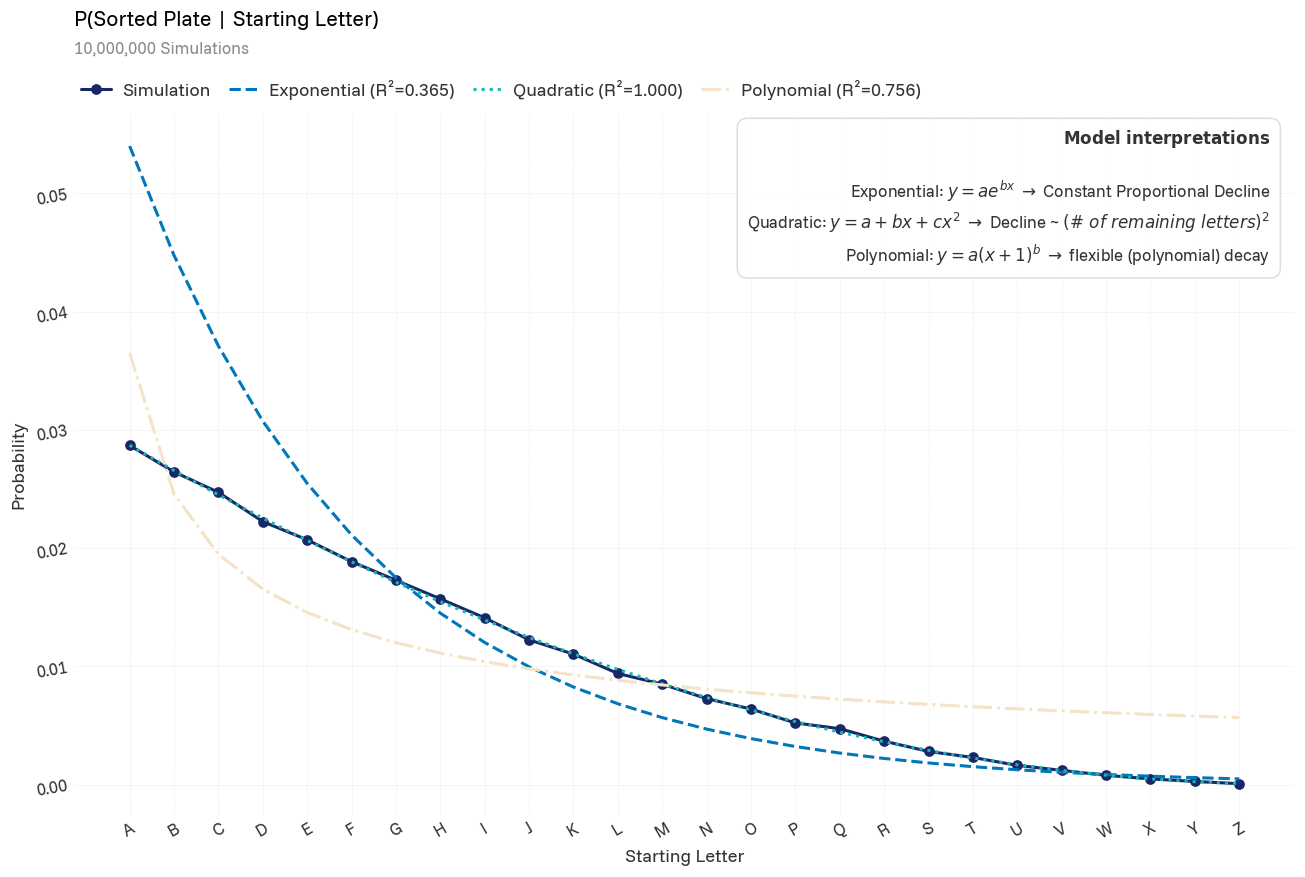

In [122]:
fig, ax = plt.subplots()

# simulated
ax.plot(
    x,
    y,
    marker="o",
    linewidth=2,
    label="Simulation",
)

# exponential
params, y_pred, r2 = fits["exponential"]
ax.plot(
    x,
    y_pred,
    linestyle="--",
    linewidth=2,
    label=f"Exponential (R²={r2:.3f})",
)

# quadratic
params, y_pred, r2 = fits["quadratic"]
ax.plot(
    x,
    y_pred,
    linestyle=":",
    linewidth=2,
    label=f"Quadratic (R²={r2:.3f})",
)

# power
params, y_pred, r2 = fits["power"]
ax.plot(
    x,
    y_pred,
    linestyle="-.",
    linewidth=2,
    label=f"Polynomial (R²={r2:.3f})",
)

ax.set_xticks(x)
ax.set_xticklabels(agg.index)

ax.set_xlabel("Starting Letter")
ax.set_ylabel("Probability")

pstyle.set_title(
    ax,
    "P(Sorted Plate | Starting Letter)",
    f"{n_simulations:,} simulations",
)

annotation = (
    r"$\mathbf{Model\ interpretations}$"
    "\n\n"
    r"Exponential: $y = ae^{bx}$ $\to$ Constant Proportional Decline"
    "\n"
    r"Quadratic: $y = a + bx + cx^2$ $\to$ Decline ~ $(\# ~of~remaining~letters)^2$"
    "\n"
    r"Polynomial: $y = a(x+1)^b$ $\to$ flexible (polynomial) decay"
)

ax.text(
    0.98,
    0.98,
    annotation,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    linespacing=1.4,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="#dddddd",
        linewidth=1,
        alpha=0.95,
    ),
)


pstyle.style_plot(ax)

plt.tight_layout()
plt.show()


# Palindromes

In [ ]:
plate_results['pal_type'] = plate_results.apply(
    lambda r: f"{len(set(r.letters))}L-{len(set(r.numbers))}N",
    axis=1
)

pal_counts = (
    plate_results[plate_results.palindrome]
    .pal_type
    .value_counts()
)

pal_counts.plot.bar(figsize=(10,6))
plt.title("Types of Palindromic Plates")
plt.ylabel("Count")
plt.xlabel("Palindrome Pattern")
